In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/laptop_selected.csv")
df

,Brand,Series,Thickness,Weight,Operating System,Display Size,Display Touchscreen,Processor,Graphic Processor,RAM_Capacity_GB,RAM Type,SSD Capacity,HDD Capacity,Battery Capacity,Fingerprint scanner,Price (Rs)
0,HP,Pavilion,17.0,1.41,Windows 10 Home Basic,14.0,No,intel core i5-1135g7 (11th gen),intel iris x,16.0,DDR4,512.0,NaN,NaN,No,71990.0
1,Acer,Predator Helios Neo 16,26.5,2.60,Windows 11 Home Basic,16.0,No,intel core i7-13700hx (13th gen),nvidia geforce rtx 4050,16.0,DDR5,512.0,NaN,NaN,NaN,105999.0
2,Dell,Inspiron 15,22.7,2.20,Windows 10 Home Basic,15.6,No,intel core i5-8250u (8th gen),amd radeon 530,8.0,DDR4,NaN,2.0,NaN,No,54999.0
3,MSI,NaN,29.0,2.20,DOS,15.6,No,intel core i7-7700hq (7th gen),nvidia geforce gtx 1050,8.0,DDR4,NaN,1.0,NaN,No,67990.0
4,Dell,Inspiron 15,23.0,1.80,Windows 11 Home Basic,15.6,No,amd dual core athlon 3050u,amd radeon,4.0,DDR4,256.0,NaN,NaN,NaN,42210.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8073,Acer,ConceptD,17.9,2.10,Windows 10 Home Basic,15.6,No,intel core i7-9750h (9th gen),nvidia geforce rtx 2080,32.0,DDR4,1.0,NaN,NaN,No,260999.0
8074,Acer,ConceptD,17.9,2.10,Windows 10 Home Basic,15.6,No,intel core i7-9750h (9th gen),nvidia geforce rtx 2080,32.0,DDR4,512.0,NaN,NaN,No,255999.0
8075,Lenovo,Thinkpad,17.0,1.22,Windows 10 Professional,13.3,No,intel core i5-10210u (10th gen),intel uhd,8.0,DDR4,512.0,NaN,NaN,No,115900.0
8076,Lenovo,Thinkpad,21.0,1.77,DOS,14.0,No,intel core i5-10210u (10th gen),intel uhd,8.0,DDR4,256.0,NaN,NaN,No,59073.0


In [3]:
X = df.drop(columns=["Price (Rs)"])
y = df["Price (Rs)"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [5]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (6462, 15)
X_test : (1616, 15)
y_train: (6462,)
y_test : (1616,)


In [6]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 6462 entries, 2487 to 7270
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Brand                6462 non-null   str    
 1   Series               5579 non-null   str    
 2   Thickness            5916 non-null   float64
 3   Weight               6232 non-null   float64
 4   Operating System     6462 non-null   str    
 5   Display Size         6460 non-null   float64
 6   Display Touchscreen  6399 non-null   str    
 7   Processor            6462 non-null   str    
 8   Graphic Processor    6399 non-null   str    
 9   RAM_Capacity_GB      6462 non-null   float64
 10  RAM Type             6351 non-null   str    
 11  SSD Capacity         5394 non-null   float64
 12  HDD Capacity         1466 non-null   float64
 13  Battery Capacity     1896 non-null   float64
 14  Fingerprint scanner  4343 non-null   str    
dtypes: float64(7), str(8)
memory usage: 807.8 KB


In [7]:
X_train.isna().sum()

Brand                     0
Series                  883
Thickness               546
Weight                  230
Operating System          0
Display Size              2
Display Touchscreen      63
Processor                 0
Graphic Processor        63
RAM_Capacity_GB           0
RAM Type                111
SSD Capacity           1068
HDD Capacity           4996
Battery Capacity       4566
Fingerprint scanner    2119
dtype: int64

In [8]:
numerical_features = [
    "Thickness",
    "Weight",
    "Display Size",
    "RAM_Capacity_GB",
    "SSD Capacity",
    "HDD Capacity",
    "Battery Capacity"
]

categorical_features = [
    "Brand",
    "Series",
    "Operating System",
    "Display Touchscreen",
    "Processor",
    "Graphic Processor",
    "RAM Type",
    "Fingerprint scanner"
]

In [9]:
print("Numerical features:")
print(X_train[numerical_features].dtypes)

print("\nCategorical features:")
print(X_train[categorical_features].dtypes)

Numerical features:
Thickness           float64
Weight              float64
Display Size        float64
RAM_Capacity_GB     float64
SSD Capacity        float64
HDD Capacity        float64
Battery Capacity    float64
dtype: object

Categorical features:
Brand                  str
Series                 str
Operating System       str
Display Touchscreen    str
Processor              str
Graphic Processor      str
RAM Type               str
Fingerprint scanner    str
dtype: object


In [10]:
print("Total features:", len(X_train.columns))
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Total features: 15
Numerical features: 7
Categorical features: 8


In [11]:
numerical_missing = pd.DataFrame({
    "Missing Count": X_train[numerical_features].isna().sum(),
    "Missing Percentage": (
        X_train[numerical_features].isna().mean() * 100
    ).round(2)
}).sort_values("Missing Percentage", ascending=False)

numerical_missing

,Missing Count,Missing Percentage
HDD Capacity,4996,77.31
Battery Capacity,4566,70.66
SSD Capacity,1068,16.53
Thickness,546,8.45
Weight,230,3.56
Display Size,2,0.03
RAM_Capacity_GB,0,0.00


In [12]:
categorical_missing = pd.DataFrame({
    "Missing Count": X_train[categorical_features].isna().sum(),
    "Missing Percentage": (
        X_train[categorical_features].isna().mean() * 100
    ).round(2),
    "Unique values":X_train[categorical_features].nunique()
}).sort_values("Missing Percentage", ascending=False)

categorical_missing

,Missing Count,Missing Percentage,Unique values
Fingerprint scanner,2119,32.79,5
Series,883,13.66,503
RAM Type,111,1.72,10
Display Touchscreen,63,0.97,2
Graphic Processor,63,0.97,313
Brand,0,0.00,35
Operating System,0,0.00,32
Processor,0,0.00,677


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [14]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [15]:
numerical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [16]:
from sklearn.preprocessing import OneHotEncoder
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [17]:
categorical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto ac

In [20]:
from sklearn.compose import ColumnTransformer

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [22]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [23]:
print("Numerical columns:")
print(preprocessor.transformers[0][2])

print("\nCategorical columns:")
print(preprocessor.transformers[1][2])

Numerical columns:
['Thickness', 'Weight', 'Display Size', 'RAM_Capacity_GB', 'SSD Capacity', 'HDD Capacity', 'Battery Capacity']

Categorical columns:
['Brand', 'Series', 'Operating System', 'Display Touchscreen', 'Processor', 'Graphic Processor', 'RAM Type', 'Fingerprint scanner']


In [24]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)


In [25]:
print("Training transformed shape:", X_train_transformed.shape)
print("Testing transformed shape:", X_test_transformed.shape)

Training transformed shape: (6462, 1584)
Testing transformed shape: (1616, 1584)


In [26]:
categorical_encoder_fitted = (
    preprocessor
    .named_transformers_["cat"]
    .named_steps["encoder"]
)

print("Number of categorical features:")
print(len(categorical_encoder_fitted.categories_))

print("\nCategories learned for each categorical feature:")
for feature, categories in zip(
    categorical_features,
    categorical_encoder_fitted.categories_
):
    print(f"{feature}: {len(categories)} categories")

Number of categorical features:
8

Categories learned for each categorical feature:
Brand: 35 categories
Series: 503 categories
Operating System: 32 categories
Display Touchscreen: 2 categories
Processor: 677 categories
Graphic Processor: 313 categories
RAM Type: 10 categories
Fingerprint scanner: 5 categories


In [27]:
print(type(preprocessor))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


# model experiments


In [28]:
print("X_train_transformed:", X_train_transformed.shape)
print("X_test_transformed :", X_test_transformed.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train_transformed: (6462, 1584)
X_test_transformed : (1616, 1584)
y_train: (6462,)
y_test : (1616,)


In [29]:
print("Target name: Price (Rs)")
print("Training target count:", len(y_train))
print("Testing target count :", len(y_test))
print("Training target missing:", y_train.isna().sum())
print("Testing target missing :", y_test.isna().sum())

Target name: Price (Rs)
Training target count: 6462
Testing target count : 1616
Training target missing: 0
Testing target missing : 0


In [30]:
numerical_imputer = (
    preprocessor
    .named_transformers_["num"]
    .named_steps["imputer"]
)

print("Numerical features:")
print(numerical_features)

print("\nValues learned by numerical imputer:")
print(numerical_imputer.statistics_)

Numerical features:
['Thickness', 'Weight', 'Display Size', 'RAM_Capacity_GB', 'SSD Capacity', 'HDD Capacity', 'Battery Capacity']

Values learned by numerical imputer:
[ 19.9    1.75  15.6    8.   512.     1.    53.  ]


In [31]:
categorical_imputer = (
    preprocessor
    .named_transformers_["cat"]
    .named_steps["imputer"]
)

print("Categorical features:")
print(categorical_features)

print("\nValues learned by categorical imputer:")
print(categorical_imputer.statistics_)

Categorical features:
['Brand', 'Series', 'Operating System', 'Display Touchscreen', 'Processor', 'Graphic Processor', 'RAM Type', 'Fingerprint scanner']

Values learned by categorical imputer:
['Asus' 'Ideapad' 'Windows 11 Home Basic' 'No'
 'intel core i5-1135g7 (11th gen)' 'intel uhd' 'DDR4' 'No']


In [32]:
scaler = (
    preprocessor
    .named_transformers_["num"]
    .named_steps["scaler"]
)

print("Scaler means:")
print(scaler.mean_)

print("\nScaler standard deviations:")
print(scaler.scale_)

Scaler means:
[ 21.3191953    1.82263386  15.00629836  11.98081089 365.9363974
   7.49257196  54.08528165]

Scaler standard deviations:
[  8.36954546   0.43944641   1.06609009   7.44888307 208.0588665
  56.52109647   8.91309875]


In [33]:
encoder = (
    preprocessor
    .named_transformers_["cat"]
    .named_steps["encoder"]
)

for feature, categories in zip(categorical_features, encoder.categories_):
    print(f"{feature}:")
    print(f"  Number of categories: {len(categories)}")
    print(f"  Categories: {categories}")
    print()

Brand:
  Number of categories: 35
  Categories: ['Acer' 'Apple' 'Asus' 'Avita' 'Coconics' 'Colorful' 'Dell' 'Fujitsu'
 'Gigabyte' 'HP' 'Honor' 'Huawei' 'Infinix' 'LG' 'Lava' 'Lenovo' 'MSI'
 'Micromax' 'Microsoft' 'Motorola' 'Nokia' 'Primebook' 'RDP' 'Razer'
 'Reliance' 'Samsung' 'Smartron' 'Tecno' 'Thomson' 'VAIO' 'Wings' 'Xiaomi'
 'Zebronics' 'iBall' 'realme']

Series:
  Number of categories: 503
  Categories: ['240' '240 G10' '240 G8' '240 G9' '240R G9' '245' '245 G10' '245 G9'
 '247' '250' '250 G9' '250R G9' '255' '255 G10' '255 G9' 'A' 'ALG'
 'Admiror' 'Alienware' 'Alienware 17' 'Alienware m16 R1'
 'Alienware m16 R2' 'Alienware m18 R2' 'Alienware x16 R2' 'Alpha 15'
 'Aspire' 'Aspire 15' 'Aspire 3' 'Aspire 3 Spin' 'Aspire 5' 'Aspire 7'
 'Aspire E' 'Aspire Lite' 'Aspire One' 'Aspire R' 'Aspire Switch'
 'Aspire Switch Alpha' 'Aspire V Nitro' 'Aspire Vero' 'Blade 14'
 'Blade 15' 'Blade Stealth' 'Bravo 15' 'CH' 'Canvas' 'Chromebook'
 'Chromebook Flip' 'Chromebook Plus' 'Chromebook Plus 

# Regression Baseline

In [34]:
from sklearn.dummy import DummyRegressor
baseline_model = DummyRegressor(strategy="mean")

In [35]:
baseline_model.fit(X_train_transformed, y_train)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None
Name,Type,Value
"constant_ constant_: ndarray of shape (1, n_outputs)Mean or median or quantile of the training targets or constant valuegiven by the user.","ndarray[float64](1, 1)",[[80205.69]]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,1584
n_outputs_ n_outputs_: intNumber of outputs.,int,1


In [36]:
baseline_predictions = baseline_model.predict(X_test_transformed)

In [37]:
print("First 10 baseline predictions:")
print(baseline_predictions[:10])
print("Number of unique baseline predictions:",len(set(baseline_predictions)))

First 10 baseline predictions:
[80205.68724853 80205.68724853 80205.68724853 80205.68724853
 80205.68724853 80205.68724853 80205.68724853 80205.68724853
 80205.68724853 80205.68724853]
Number of unique baseline predictions: 1


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [39]:
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

In [40]:
print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²  :", baseline_r2)

Baseline MAE : 41726.691520266235
Baseline RMSE: 61234.986992112135
Baseline R²  : -0.0010348986590056342


In [41]:
results = []

results.append({
    "Model": "Dummy Baseline",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "R2": baseline_r2
})

In [42]:
pd.DataFrame(results)

,Model,MAE,RMSE,R2
0,Dummy Baseline,41726.69152,61234.986992,-0.001035


# Candidate Models

In [43]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [44]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "gradient_boosting_model" : GradientBoostingRegressor(
        random_state=42
    ),
}

In [45]:
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train_transformed, y_train)
    
    trained_models[name] = model
    
    print(f"{name} training complete.\n")

Training Linear Regression...
Linear Regression training complete.

Training Ridge Regression...
Ridge Regression training complete.

Training Random Forest...
Random Forest training complete.

Training gradient_boosting_model...
gradient_boosting_model training complete.



In [46]:
print("Number of trained models:", len(trained_models))

for name, model in trained_models.items():
    print(name, "→", type(model).__name__)

Number of trained models: 4
Linear Regression → LinearRegression
Ridge Regression → Ridge
Random Forest → RandomForestRegressor
gradient_boosting_model → GradientBoostingRegressor


In [47]:
predictions = {}

for name, model in trained_models.items():
    predictions[name] = model.predict(X_test_transformed)
    
    print(f"{name}:")
    print("  Predictions:", len(predictions[name]))
    print("  First 5:", predictions[name][:5])
    print()

Linear Regression:
  Predictions: 1616
  First 5: [ 24815.34405573  51169.44664045  84388.12806218 106308.92006829
  60917.86088131]

Ridge Regression:
  Predictions: 1616
  First 5: [ 51826.87958182  39318.81093245  83228.48869518 107828.03287909
  67826.92014472]

Random Forest:
  Predictions: 1616
  First 5: [30060.30633333 27046.00066667 74964.535      94989.9
 62039.49333333]

gradient_boosting_model:
  Predictions: 1616
  First 5: [ 38415.89002964  38415.89002964  63853.47908316 103351.86304621
  92930.6894029 ]



In [48]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Linear Regression": predictions["Linear Regression"],
    "Ridge Regression": predictions["Ridge Regression"],
    "Random Forest": predictions["Random Forest"]
})

comparison.head(10)

,Actual Price,Linear Regression,Ridge Regression,Random Forest
0,40944.0,24815.344056,51826.879582,30060.306333
1,35150.0,51169.446640,39318.810932,27046.000667
2,74990.0,84388.128062,83228.488695,74964.535000
3,149990.0,106308.920068,107828.032879,94989.900000
4,62990.0,60917.860881,67826.920145,62039.493333
5,31990.0,37323.290026,36910.767719,38885.081667
6,47990.0,61670.584910,63277.223468,69568.350000
7,254490.0,132510.704793,142552.256338,213193.971250
8,47990.0,52150.494599,49543.321387,52545.557500
9,47900.0,62678.404119,61847.243347,50763.569000


In [49]:
evaluation_results = []

for name, prediction in predictions.items():

    mae = mean_absolute_error(y_test, prediction)

    rmse = np.sqrt(mean_squared_error(y_test, prediction))

    r2 = r2_score(y_test, prediction)

    evaluation_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

In [50]:
evaluation_results.insert(0, {
    "Model": "Dummy Baseline",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "R2": baseline_r2
})

In [51]:
evaluation_df = pd.DataFrame(evaluation_results)
evaluation_df

,Model,MAE,RMSE,R2
0,Dummy Baseline,41726.691520,61234.986992,-0.001035
1,Linear Regression,12777.249692,21461.210113,0.877042
2,Ridge Regression,12720.361301,20290.929394,0.890086
3,Random Forest,13012.766282,22566.094733,0.864055
4,gradient_boosting_model,17757.866697,26339.483425,0.814790


In [52]:
evaluation_display = evaluation_df.copy()

evaluation_display["MAE"] = evaluation_display["MAE"].round(2)
evaluation_display["RMSE"] = evaluation_display["RMSE"].round(2)
evaluation_display["R2"] = evaluation_display["R2"].round(4)

evaluation_display

,Model,MAE,RMSE,R2
0,Dummy Baseline,41726.69,61234.99,-0.0010
1,Linear Regression,12777.25,21461.21,0.8770
2,Ridge Regression,12720.36,20290.93,0.8901
3,Random Forest,13012.77,22566.09,0.8641
4,gradient_boosting_model,17757.87,26339.48,0.8148


In [53]:
print(evaluation_display)

                     Model       MAE      RMSE      R2
0           Dummy Baseline  41726.69  61234.99 -0.0010
1        Linear Regression  12777.25  21461.21  0.8770
2         Ridge Regression  12720.36  20290.93  0.8901
3            Random Forest  13012.77  22566.09  0.8641
4  gradient_boosting_model  17757.87  26339.48  0.8148


# Model Comparison

In [54]:
comparison_by_r2 = evaluation_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

comparison_by_r2

,Model,MAE,RMSE,R2
0,Ridge Regression,12720.361301,20290.929394,0.890086
1,Linear Regression,12777.249692,21461.210113,0.877042
2,Random Forest,13012.766282,22566.094733,0.864055
3,gradient_boosting_model,17757.866697,26339.483425,0.814790
4,Dummy Baseline,41726.691520,61234.986992,-0.001035


In [55]:
comparison_by_mae = evaluation_df.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

comparison_by_mae

,Model,MAE,RMSE,R2
0,Ridge Regression,12720.361301,20290.929394,0.890086
1,Linear Regression,12777.249692,21461.210113,0.877042
2,Random Forest,13012.766282,22566.094733,0.864055
3,gradient_boosting_model,17757.866697,26339.483425,0.814790
4,Dummy Baseline,41726.691520,61234.986992,-0.001035


In [56]:
comparison_by_rmse = evaluation_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

comparison_by_rmse

,Model,MAE,RMSE,R2
0,Ridge Regression,12720.361301,20290.929394,0.890086
1,Linear Regression,12777.249692,21461.210113,0.877042
2,Random Forest,13012.766282,22566.094733,0.864055
3,gradient_boosting_model,17757.866697,26339.483425,0.814790
4,Dummy Baseline,41726.691520,61234.986992,-0.001035


# Cross-Validation

In [57]:
from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [58]:
fold_number = 1

for train_indices, validation_indices in cv.split(X_train):
    print(f"Fold {fold_number}")
    print("Training rows  :", len(train_indices))
    print("Validation rows:", len(validation_indices))
    print()
    
    fold_number += 1

Fold 1
Training rows  : 5169
Validation rows: 1293

Fold 2
Training rows  : 5169
Validation rows: 1293

Fold 3
Training rows  : 5170
Validation rows: 1292

Fold 4
Training rows  : 5170
Validation rows: 1292

Fold 5
Training rows  : 5170
Validation rows: 1292



In [59]:
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Thickness', 'Weight', 'Display Size',
                                  'RAM_Capacity_GB', 'SSD Capacity',
                                  'HDD Capacity', 'Battery Capacity']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Brand', 'Series', 'Operating System',
                                  'Display Touchscreen', 'Processor',
                             

In [60]:
ridge_cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

In [61]:
ridge_cv_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [62]:
from sklearn.model_selection import cross_validate

In [63]:
ridge_cv_results = cross_validate(
    ridge_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    return_train_score=False
)

In [64]:
ridge_cv_mae = -ridge_cv_results["test_MAE"]
ridge_cv_rmse = -ridge_cv_results["test_RMSE"]
ridge_cv_r2 = ridge_cv_results["test_R2"]

In [65]:
import pandas as pd

ridge_cv_fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "MAE": ridge_cv_mae,
    "RMSE": ridge_cv_rmse,
    "R2": ridge_cv_r2
})

ridge_cv_fold_results

,Fold,MAE,RMSE,R2
0,1,12422.311649,19479.023675,0.894282
1,2,13298.888747,22534.239131,0.862708
2,3,12439.131099,21401.905685,0.866438
3,4,12647.221428,20493.791926,0.867295
4,5,13420.208817,21983.397704,0.859231


In [66]:
print("Mean CV MAE :", ridge_cv_mae.mean())
print("Mean CV RMSE:", ridge_cv_rmse.mean())
print("Mean CV R²  :", ridge_cv_r2.mean())

Mean CV MAE : 12845.552348150217
Mean CV RMSE: 21178.47162409347
Mean CV R²  : 0.8699906057108793


In [67]:
print("Std CV MAE :", ridge_cv_mae.std())
print("Std CV RMSE:", ridge_cv_rmse.std())
print("Std CV R²  :", ridge_cv_r2.std())

Std CV MAE : 428.80998647226
Std CV RMSE: 1085.6190792306008
Std CV R²  : 0.012480140734879156


In [68]:

linear_cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [69]:
linear_cv_results = cross_validate(
    linear_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    return_train_score=False
)

In [70]:
linear_cv_mae = -linear_cv_results["test_MAE"]
linear_cv_rmse = -linear_cv_results["test_RMSE"]
linear_cv_r2 = linear_cv_results["test_R2"]

In [71]:
linear_cv_fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "MAE": linear_cv_mae,
    "RMSE": linear_cv_rmse,
    "R2": linear_cv_r2
})

linear_cv_fold_results

,Fold,MAE,RMSE,R2
0,1,12079.946983,20473.875872,0.883207
1,2,12636.500788,22415.637240,0.864150
2,3,12195.607531,22244.654114,0.855712
3,4,13426.131847,23734.222039,0.822011
4,5,13647.129915,23982.879643,0.832459


In [72]:
print("Mean CV MAE :", linear_cv_mae.mean())
print("Mean CV RMSE:", linear_cv_rmse.mean())
print("Mean CV R²  :", linear_cv_r2.mean())

print("Std CV MAE :", linear_cv_mae.std())
print("Std CV RMSE:", linear_cv_rmse.std())
print("Std CV R²  :", linear_cv_r2.std())


Mean CV MAE : 12797.063412712578
Mean CV RMSE: 22570.25378160885
Mean CV R²  : 0.8515077270699969
Std CV MAE : 635.629713331632
Std CV RMSE: 1254.994477081794
Std CV R²  : 0.021978631296589675


In [73]:

random_forest_cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            random_state=42
        ))
    ]
)

In [74]:
random_forest_cv_results = cross_validate(
    random_forest_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    return_train_score=False
)

In [75]:
random_forest_cv_mae = -random_forest_cv_results["test_MAE"]
random_forest_cv_rmse = -random_forest_cv_results["test_RMSE"]
random_forest_cv_r2 = random_forest_cv_results["test_R2"]

In [76]:
random_forest_cv_fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "MAE": random_forest_cv_mae,
    "RMSE": random_forest_cv_rmse,
    "R2": random_forest_cv_r2
})

random_forest_cv_fold_results

,Fold,MAE,RMSE,R2
0,1,12589.073082,21386.757394,0.872560
1,2,13626.741483,23870.062256,0.845949
2,3,12508.213672,22585.625740,0.851255
3,4,12729.342809,21629.232826,0.852182
4,5,13961.571076,24541.332026,0.824566


In [77]:
print("Mean CV MAE :", random_forest_cv_mae.mean())
print("Mean CV RMSE:", random_forest_cv_rmse.mean())
print("Mean CV R²  :", random_forest_cv_r2.mean())

print("Std CV MAE :", random_forest_cv_mae.std())
print("Std CV RMSE:", random_forest_cv_rmse.std())
print("Std CV R²  :", random_forest_cv_r2.std())

Mean CV MAE : 13082.98842423406
Mean CV RMSE: 22802.602048398396
Mean CV R²  : 0.8493022898084261
Std CV MAE : 594.4675713348588
Std CV RMSE: 1232.164223302551
Std CV R²  : 0.015337481265392392


In [78]:
 
gradient_boosting_cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=42
        ))
    ]
)

In [79]:
gradient_boosting_cv_results = cross_validate(
    gradient_boosting_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    return_train_score=False
)

In [80]:
gradient_boosting_cv_mae = -gradient_boosting_cv_results["test_MAE"]
gradient_boosting_cv_rmse = -gradient_boosting_cv_results["test_RMSE"]
gradient_boosting_cv_r2 = gradient_boosting_cv_results["test_R2"]

In [81]:
gradient_boosting_cv_fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "MAE": gradient_boosting_cv_mae,
    "RMSE": gradient_boosting_cv_rmse,
    "R2": gradient_boosting_cv_r2
})

gradient_boosting_cv_fold_results

,Fold,MAE,RMSE,R2
0,1,16962.383097,25391.469398,0.820365
1,2,17425.516337,27441.674887,0.796399
2,3,16567.314078,25690.641285,0.807545
3,4,16876.734432,24985.816927,0.802744
4,5,17515.995519,26876.118121,0.789597


In [82]:
print("Mean CV MAE :", gradient_boosting_cv_mae.mean())
print("Mean CV RMSE:", gradient_boosting_cv_rmse.mean())
print("Mean CV R²  :", gradient_boosting_cv_r2.mean())

print("Std CV MAE :", gradient_boosting_cv_mae.std())
print("Std CV RMSE:", gradient_boosting_cv_rmse.std())
print("Std CV R²  :", gradient_boosting_cv_r2.std())

Mean CV MAE : 17069.58869239806
Mean CV RMSE: 26077.144123343074
Mean CV R²  : 0.8033299973256154
Std CV MAE : 354.0986125629175
Std CV RMSE: 928.5292647441161
Std CV R²  : 0.010439692012528288


In [83]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Mean CV MAE": [
        linear_cv_mae.mean(),
        ridge_cv_mae.mean(),
        random_forest_cv_mae.mean(),
        gradient_boosting_cv_mae.mean()
    ],
    "Mean CV RMSE": [
        linear_cv_rmse.mean(),
        ridge_cv_rmse.mean(),
        random_forest_cv_rmse.mean(),
        gradient_boosting_cv_rmse.mean()
    ],
    "Mean CV R2": [
        linear_cv_r2.mean(),
        ridge_cv_r2.mean(),
        random_forest_cv_r2.mean(),
        gradient_boosting_cv_r2.mean()
    ],
    "Std CV MAE": [
        linear_cv_mae.std(),
        ridge_cv_mae.std(),
        random_forest_cv_mae.std(),
        gradient_boosting_cv_mae.std()
    ],
    "Std CV RMSE": [
        linear_cv_rmse.std(),
        ridge_cv_rmse.std(),
        random_forest_cv_rmse.std(),
        gradient_boosting_cv_rmse.std()
    ],
    "Std CV R2": [
        linear_cv_r2.std(),
        ridge_cv_r2.std(),
        random_forest_cv_r2.std(),
        gradient_boosting_cv_r2.std()
    ]
})

cv_comparison

,Model,Mean CV MAE,Mean CV RMSE,Mean CV R2,Std CV MAE,Std CV RMSE,Std CV R2
0,Linear Regression,12797.063413,22570.253782,0.851508,635.629713,1254.994477,0.021979
1,Ridge Regression,12845.552348,21178.471624,0.869991,428.809986,1085.619079,0.012480
2,Random Forest,13082.988424,22802.602048,0.849302,594.467571,1232.164223,0.015337
3,Gradient Boosting,17069.588692,26077.144123,0.803330,354.098613,928.529265,0.010440


# tuning

In [84]:
ridge_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

In [85]:
ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100, 1000]
}

In [86]:
from sklearn.model_selection import GridSearchCV

In [87]:
ridge_grid_search = GridSearchCV(
    estimator=ridge_tuning_pipeline,
    param_grid=ridge_param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=False
)

In [88]:
ridge_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls

In [89]:
print("Best alpha:", ridge_grid_search.best_params_)
print("Best CV RMSE:", -ridge_grid_search.best_score_)

Best alpha: {'model__alpha': 1}
Best CV RMSE: 21178.47162409347


In [90]:
ridge_tuning_results = pd.DataFrame(
    ridge_grid_search.cv_results_
)

ridge_tuning_results[
    [
        "param_model__alpha",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

,param_model__alpha,mean_test_score,std_test_score,rank_test_score
2,1.00,-21178.471624,1085.619079,1
1,0.10,-21536.030728,956.429684,2
0,0.01,-22348.055277,1180.093832,3
3,10.00,-24204.916645,1392.353386,4
4,100.00,-29153.064204,1324.184944,5
5,1000.00,-33301.325963,1041.153993,6


In [91]:
ridge_tuning_results["mean_RMSE"] = (
    -ridge_tuning_results["mean_test_score"]
)

ridge_tuning_results[
    [
        "param_model__alpha",
        "mean_RMSE",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

,param_model__alpha,mean_RMSE,std_test_score,rank_test_score
2,1.00,21178.471624,1085.619079,1
1,0.10,21536.030728,956.429684,2
0,0.01,22348.055277,1180.093832,3
3,10.00,24204.916645,1392.353386,4
4,100.00,29153.064204,1324.184944,5
5,1000.00,33301.325963,1041.153993,6


In [92]:
random_forest_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            random_state=42
        ))
    ]
)

In [93]:
random_forest_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 20],
    "model__min_samples_leaf": [1, 2]
}

In [94]:
random_forest_grid_search = GridSearchCV(
    estimator=random_forest_tuning_pipeline,
    param_grid=random_forest_param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=False
)

In [95]:
random_forest_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 20], 'model__min_samples_leaf': [1, 2], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support f

In [96]:
print("Best parameters:")
print(random_forest_grid_search.best_params_)

print("\nBest CV RMSE:")
print(-random_forest_grid_search.best_score_)

Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}

Best CV RMSE:
22775.832874342253


In [97]:
random_forest_tuning_results = pd.DataFrame(
    random_forest_grid_search.cv_results_
)

random_forest_tuning_results["mean_RMSE"] = (
    -random_forest_tuning_results["mean_test_score"]
)

random_forest_tuning_results[
    [
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_leaf",
        "mean_RMSE",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,mean_RMSE,rank_test_score
1,200,None,1,22775.832874,1
0,100,None,1,22802.602048,2
3,200,None,2,23225.150213,3
2,100,None,2,23232.878106,4
5,200,20,1,23324.264267,5
4,100,20,1,23343.764808,6
7,200,20,2,23431.171523,7
6,100,20,2,23457.052572,8


# evaluation

In [ ]:
final_ridge_model = Ridge(alpha=1)
final_ridge_model.fit(X_train_transformed,y_train)
final_predictions = final_ridge_model.predict(X_test_transformed)

In [ ]:
final_mae = mean_absolute_error(y_test,final_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test,final_predictions))
final_r2 = r2_score(y_test,final_predictions)

print("Final Ridge Test MAE :", final_mae)
print("Final Ridge Test RMSE:", final_rmse)
print("Final Ridge Test R²  :", final_r2)

Final Ridge Test MAE : 12720.36130129627
Final Ridge Test RMSE: 20290.92939416452
Final Ridge Test R²  : 0.8900857912500585


In [100]:
error_analysis = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": final_predictions
})

error_analysis["Error"] = (
    error_analysis["Actual Price"]
    - error_analysis["Predicted Price"]
)

error_analysis["Absolute Error"] = (
    error_analysis["Error"].abs()
)

error_analysis["Percentage Error"] = (
    error_analysis["Absolute Error"]
    / error_analysis["Actual Price"]
    * 100
)

error_analysis.head()

,Actual Price,Predicted Price,Error,Absolute Error,Percentage Error
0,40944.0,51826.879582,-10882.879582,10882.879582,26.579913
1,35150.0,39318.810932,-4168.810932,4168.810932,11.860060
2,74990.0,83228.488695,-8238.488695,8238.488695,10.986116
3,149990.0,107828.032879,42161.967121,42161.967121,28.109852
4,62990.0,67826.920145,-4836.920145,4836.920145,7.678870


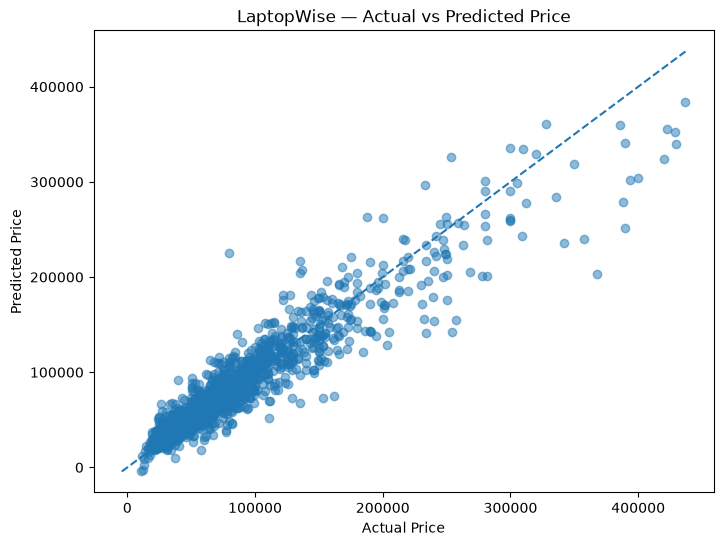

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    error_analysis["Actual Price"],
    error_analysis["Predicted Price"],
    alpha=0.5
)

min_price = min(
    error_analysis["Actual Price"].min(),
    error_analysis["Predicted Price"].min()
)

max_price = max(
    error_analysis["Actual Price"].max(),
    error_analysis["Predicted Price"].max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("LaptopWise — Actual vs Predicted Price")

plt.show()

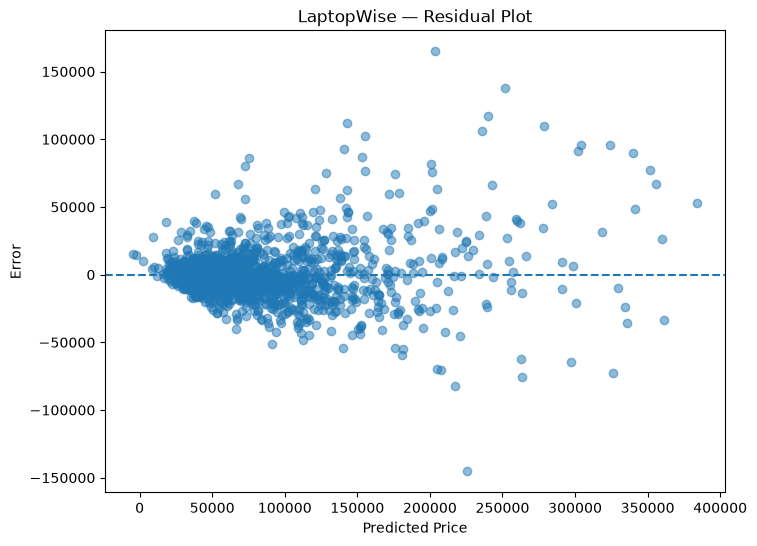

In [102]:
plt.figure(figsize=(8, 6))

plt.scatter(
    error_analysis["Predicted Price"],
    error_analysis["Error"],
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Error")
plt.title("LaptopWise — Residual Plot")

plt.show()

In [116]:
largest_errors = (
    error_analysis
    .sort_values(
        by="Absolute Error",
        ascending=False
    )
    .head(10)
)
largest_errors[
    [
        "Actual Price",
        "Predicted Price",
        "Error",
        "Absolute Error",
        "Percentage Error"
    ]
]

,Actual Price,Predicted Price,Error,Absolute Error,Percentage Error
1524,367990.0,203174.134913,164815.865087,164815.865087,44.788137
382,79990.0,225393.776263,-145403.776263,145403.776263,181.777443
1364,389990.0,251839.795128,138150.204872,138150.204872,35.424038
926,357189.0,240117.362341,117071.637659,117071.637659,32.775824
7,254490.0,142552.256338,111937.743662,111937.743662,43.985125
1307,388490.0,278806.861352,109683.138648,109683.138648,28.233195
1581,341814.0,235589.379955,106224.620045,106224.620045,31.076732
827,257490.0,155304.877887,102185.122113,102185.122113,39.685084
76,399990.0,304145.862159,95844.137841,95844.137841,23.961634
473,419990.0,324351.872149,95638.127851,95638.127851,22.771525


In [104]:
error_analysis["Actual Price"].describe()

count      1616.000000
mean      82174.588490
std       61222.271028
min       10990.000000
25%       41990.000000
50%       64990.000000
75%       98990.250000
max      436990.000000
Name: Actual Price, dtype: float64

In [105]:
error_analysis["Price Segment"] = pd.qcut(
    error_analysis["Actual Price"],
    q=4,
    labels=[
        "Budget",
        "Lower-Mid",
        "Upper-Mid",
        "High-End"
    ]
)

In [106]:
segment_analysis = (
    error_analysis
    .groupby("Price Segment", observed=False)
    .agg(
        Samples=("Actual Price", "size"),
        MAE=("Absolute Error", "mean"),
        RMSE=("Error", lambda x: np.sqrt(np.mean(x ** 2)))
    )
    .reset_index()
)

segment_analysis

,Price Segment,Samples,MAE,RMSE
0,Budget,405,6902.979715,9642.314757
1,Lower-Mid,404,8280.241112,11259.560761
2,Upper-Mid,403,11338.729593,16240.746018
3,High-End,404,24370.474364,34114.457795


In [107]:
bias_by_segment = (
    error_analysis
    .groupby("Price Segment", observed=False)
    .agg(
        Mean_Error=("Error", "mean")
    )
    .reset_index()
)

bias_by_segment

,Price Segment,Mean_Error
0,Budget,-4231.428367
1,Lower-Mid,-2757.474591
2,Upper-Mid,-1853.495828
3,High-End,8817.967560


In [108]:
error_analysis[
    ["Actual Price", "Predicted Price", "Error"]
].corr()

,Actual Price,Predicted Price,Error
Actual Price,1.000000,0.944331,0.443083
Predicted Price,0.944331,1.000000,0.123479
Error,0.443083,0.123479,1.000000


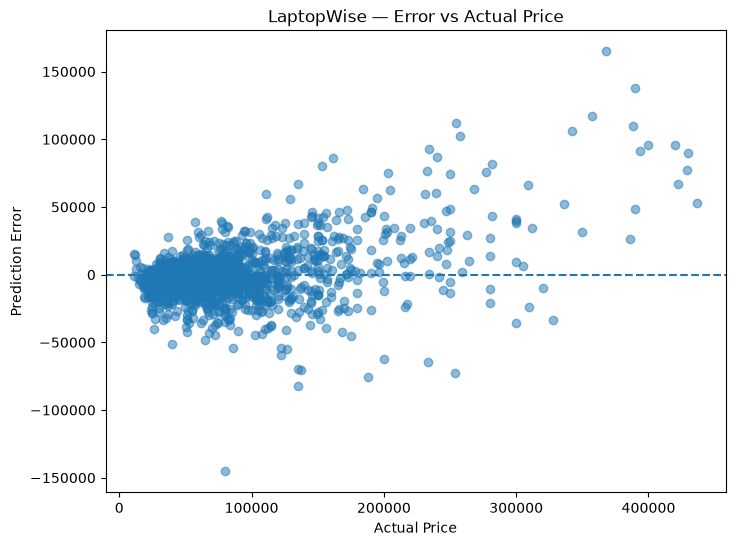

In [109]:
plt.figure(figsize=(8, 6))

plt.scatter(
    error_analysis["Actual Price"],
    error_analysis["Error"],
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.xlabel("Actual Price")
plt.ylabel("Prediction Error")
plt.title("LaptopWise — Error vs Actual Price")

plt.show()